In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [2]:
import zipfile

# Extract ZIP file
zip_ref = zipfile.ZipFile('/content/archive (5).zip', 'r')

zip_ref.extractall('/content/dataset')

zip_ref.close()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [3]:
import os

print(os.listdir('/content/dataset'))

['val', 'train.csv', 'train', 'val.csv']


In [4]:
import numpy as np
import cv2
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
train_path = '/content/dataset/train'

val_path = '/content/dataset/val'

print("Paths Loaded Successfully!")

Paths Loaded Successfully!


In [6]:
print(os.listdir(train_path))

['cat', 'dog', 'classname.txt']


In [7]:
IMG_SIZE = 128

In [8]:
from skimage.feature import hog

def load_images(folder_path):

    data = []

    labels = []

    original_images = []

    categories = ['cat', 'dog']

    for category in categories:

        path = os.path.join(folder_path, category)

        label = categories.index(category)

        for img in os.listdir(path):

            try:

                img_path = os.path.join(path, img)

                image = cv2.imread(img_path)

                image = cv2.resize(image, (128,128))

                rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

                # HOG Feature Extraction
                features = hog(
                    gray,
                    pixels_per_cell=(8,8),
                    cells_per_block=(2,2),
                    feature_vector=True
                )

                data.append(features)

                labels.append(label)

                original_images.append(rgb_image)

            except:
                pass

    return np.array(data), np.array(labels), np.array(original_images)

In [9]:
X_train, y_train, train_images = load_images(train_path)

print("Training Data Shape:", X_train.shape)

Training Data Shape: (275, 8100)


In [10]:
X_test, y_test, test_images = load_images(val_path)

print("Validation Data Shape:", X_test.shape)

Validation Data Shape: (70, 8100)


In [11]:
# Normalize pixel values
X_train = X_train / 255.0

X_test = X_test / 255.0

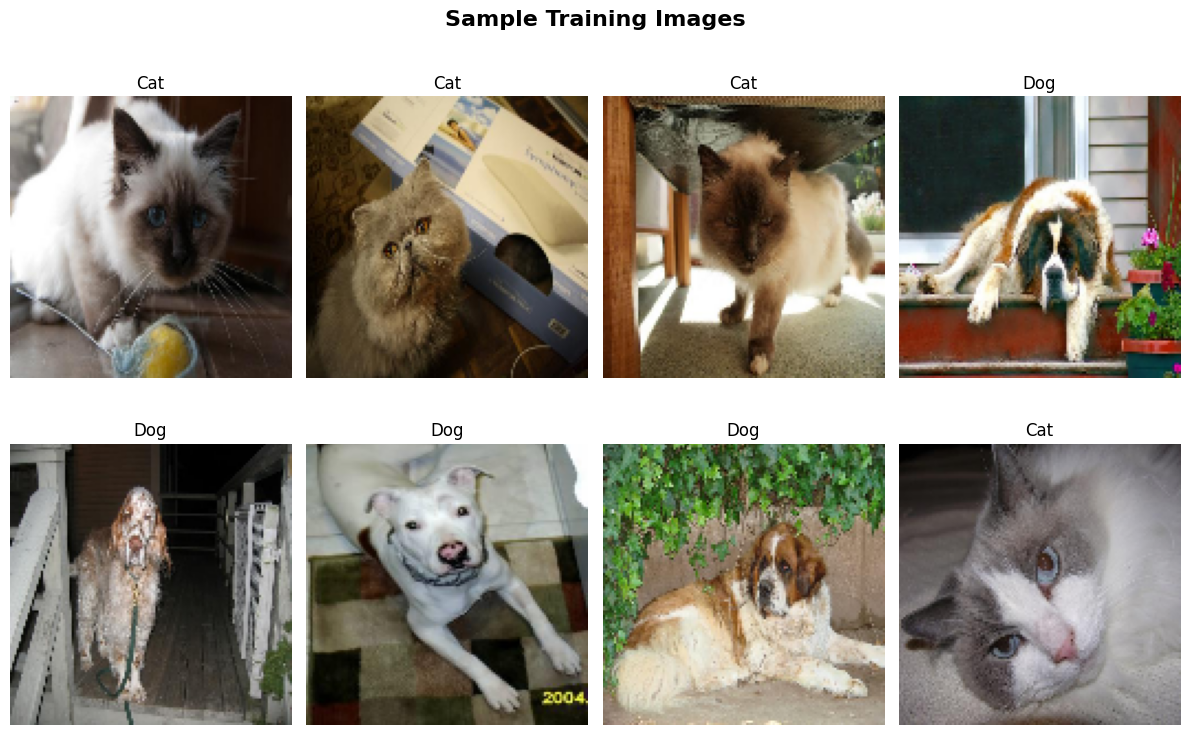

In [12]:
categories = ['Cat', 'Dog']

plt.figure(figsize=(12,8))

random_indices = np.random.choice(len(train_images), 8)

for i, idx in enumerate(random_indices):

    plt.subplot(2,4,i+1)

    plt.imshow(train_images[idx])

    plt.title(categories[y_train[idx]])

    plt.axis('off')

plt.suptitle(
    'Sample Training Images',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [13]:
svm_model = SVC(
    kernel='linear',
    C=1
)

print("Training Improved SVM Model...")

svm_model.fit(X_train, y_train)

print("Training Completed!")

Training Improved SVM Model...
Training Completed!


In [14]:
y_pred = svm_model.predict(X_test)

print("Predictions Completed!")

Predictions Completed!


In [15]:
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 65.71%


In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Cat', 'Dog']
))

              precision    recall  f1-score   support

         Cat       0.00      0.00      0.00        24
         Dog       0.66      1.00      0.79        46

    accuracy                           0.66        70
   macro avg       0.33      0.50      0.40        70
weighted avg       0.43      0.66      0.52        70



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


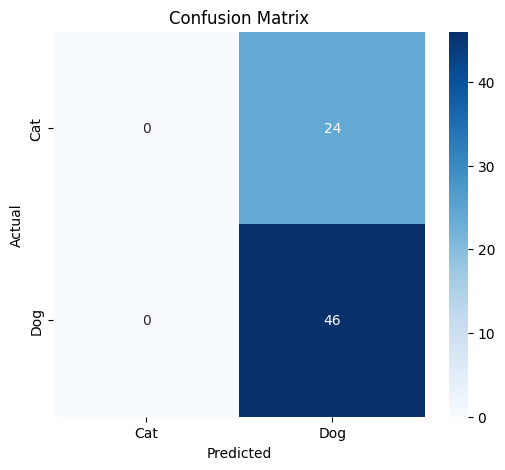

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

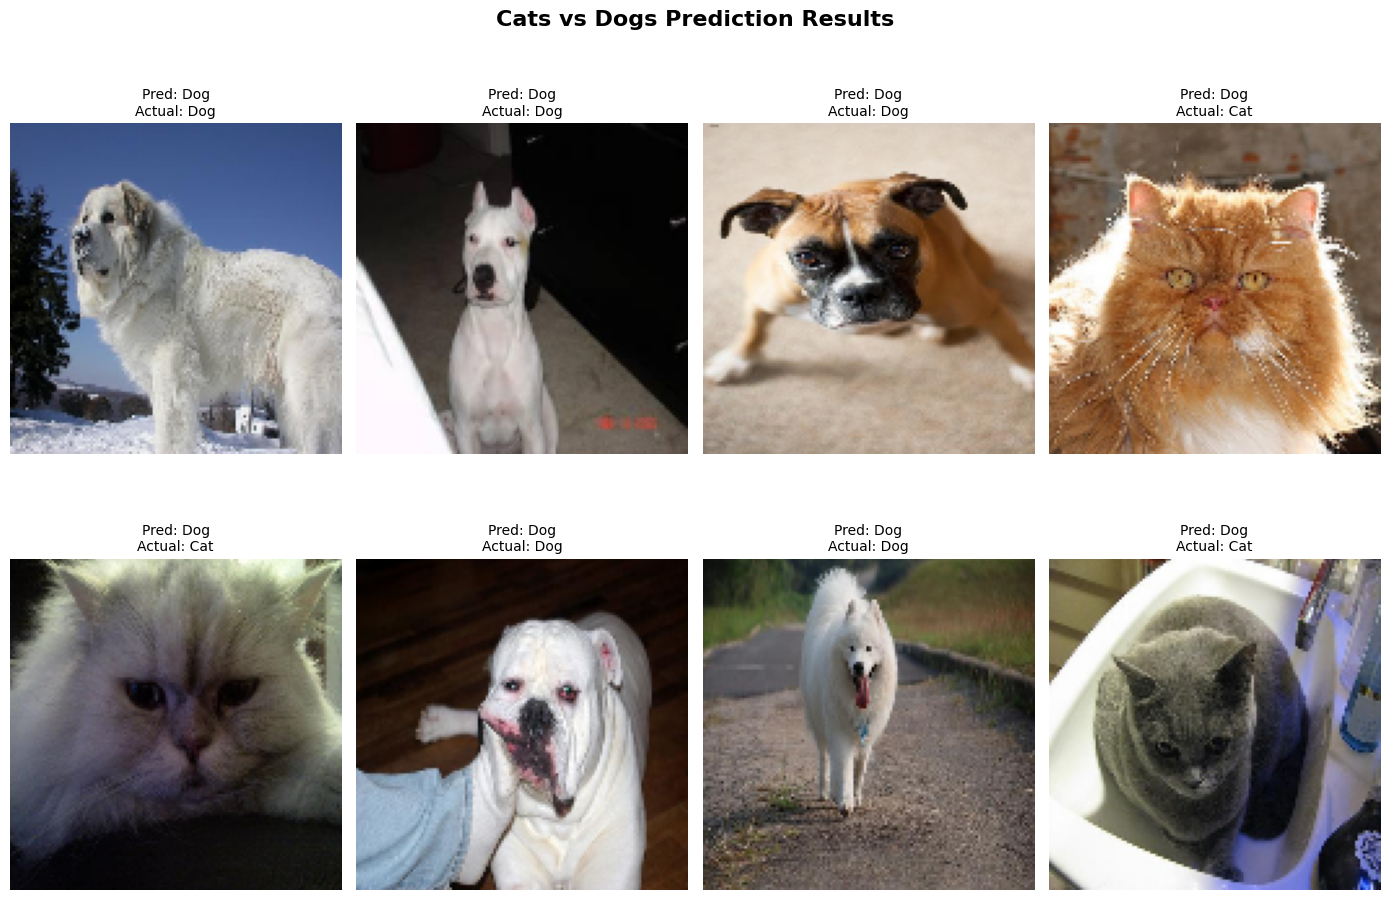

In [20]:
plt.figure(figsize=(14,10))

categories = ['Cat', 'Dog']

random_indices = np.random.choice(len(X_test), 8)

for i, idx in enumerate(random_indices):

    plt.subplot(2,4,i+1)

    prediction = svm_model.predict([X_test[idx]])[0]

    predicted_label = categories[prediction]

    actual_label = categories[y_test[idx]]

    plt.imshow(test_images[idx])

    plt.title(
        f'Pred: {predicted_label}\nActual: {actual_label}',
        fontsize=10
    )

    plt.axis('off')

plt.suptitle(
    'Cats vs Dogs Prediction Results',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [21]:
print("\n========== PROJECT SUMMARY ==========\n")

print("Project: Cats vs Dogs Image Classification")

print("Algorithm: Support Vector Machine (SVM)")

print("Classes:")
print("- Cats")
print("- Dogs")

print("\nTask Completed Successfully!")


========== PROJECT SUMMARY ==========

Project: Cats vs Dogs Image Classification
Algorithm: Support Vector Machine (SVM)
Classes:
- Cats
- Dogs

Task Completed Successfully!
